In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 1_f.csv - 1_f.csv (2).csv to 1_f.csv - 1_f.csv (2).csv


In [ ]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.fft import fft
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('1_f.csv', header=None)
rr_intervals = df[0].values

In [ ]:
print(f"Количество кардиоинтервалов: {len(rr_intervals)}")
print(f"Диапазон значений: {np.min(rr_intervals):.2f} - {np.max(rr_intervals):.2f} мс")
print(f"Среднее значение: {np.mean(rr_intervals):.2f} мс\n")

Количество кардиоинтервалов: 300
Диапазон значений: 615.00 - 844.00 мс
Среднее значение: 744.80 мс



In [ ]:
# 1. I. Построение временных точек для кардиоритмограммы

In [ ]:
time_cumsum = np.cumsum(rr_intervals) / 1000
time_points = np.insert(time_cumsum, 0, 0)[:-1]

In [ ]:
# 2. Интерполяция кубическими сплайнами

In [ ]:
dt = 0.25  # Шаг дискретизации 250 мс
cs = CubicSpline(time_points, rr_intervals)
time_resampled = np.arange(0, time_points[-1], dt)
rr_resampled = cs(time_resampled)

N = len(rr_resampled)
print(f"Количество точек после интерполяции: {N}")

Количество точек после интерполяции: 891


In [ ]:
# 2.1. Применение окна Ханна

In [ ]:
window = np.hanning(N)
rr_windowed = rr_resampled * window

In [ ]:
# 3. Быстрое преобразование Фурье (БПФ)

In [ ]:
fft_result = fft(rr_windowed)
fft_magnitude = np.abs(fft_result)

In [ ]:
# 4. Расчет спектральной плотности мощности (СПМ)

In [ ]:
psd = (fft_magnitude ** 2) / N

In [ ]:
# Переход к одностороннему спектру
N_half = N // 2
psd_single = psd[:N_half] * 2

# Частотная ось
fs = 1 / dt  # Частота дискретизации (4 Гц)
frequencies = np.fft.fftfreq(N, dt)[:N_half]

In [ ]:
# 5. Определение частотных диапазонов согласно таблице

In [ ]:
HF_range = (0.15, 0.4)
LF_range = (0.04, 0.15)
VLF_range = (0.015, 0.04)
ULF_range = (0.003, 0.015)

In [ ]:
def calculate_power_in_band(frequencies, psd, freq_range):

    mask = (frequencies >= freq_range[0]) & (frequencies <= freq_range[1])
    power = np.trapz(psd[mask], frequencies[mask])

    if np.any(mask):
        max_power = np.max(psd[mask])
        min_power = np.min(psd[mask])
    else:
        max_power = 0
        min_power = 0

    return power, max_power, min_power

In [ ]:
# 6. Расчет мощностей в каждом диапазоне

In [ ]:
HF_power, HFmax, HFmin = calculate_power_in_band(frequencies, psd_single, HF_range)
LF_power, LFmax, LFmin = calculate_power_in_band(frequencies, psd_single, LF_range)
VLF_power, VLFmax, VLFmin = calculate_power_in_band(frequencies, psd_single, VLF_range)
ULF_power, ULFmax, ULFmin = calculate_power_in_band(frequencies, psd_single, ULF_range)

TP = HF_power + LF_power + VLF_power + ULF_power

HF_percent = (HF_power / TP) * 100
LF_percent = (LF_power / TP) * 100
VLF_percent = (VLF_power / TP) * 100
ULF_percent = (ULF_power / TP) * 100

/tmp/ipython-input-2475895271.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power = np.trapz(psd[mask], frequencies[mask])


In [ ]:
# 7. Расчет индексов

In [ ]:
IC = (LF_power + VLF_power) / HF_power
LF_HF_ratio = LF_power / HF_power
ISCA = VLF_power / (HF_power + LF_power)

In [ ]:
# output

In [ ]:
print("Результат")
print(f"\nСуммарная мощность спектра (TP): {TP:.2f} мс²\n")
print("Мощности в диапазонах:")
print(f"  HF (0.15-0.4 Гц):   {HF_power:7.2f} ({HF_percent:5.2f}%)")
print(f"    HFmax: {HFmax:.2f}, HFmin: {HFmin:.2f} ")
print(f"  LF (0.04-0.15 Гц):  {LF_power:7.2f} ({LF_percent:5.2f}%)")
print(f"    LFmax: {LFmax:.2f}, LFmin: {LFmin:.2f} ")
print(f"  VLF (0.015-0.04 Гц):{VLF_power:7.2f} мс² ({VLF_percent:5.2f}%)")
print(f"    VLFmax: {VLFmax:.2f}, VLFmin: {VLFmin:.2f}")
print(f"  ULF (0.003-0.015 Гц):{ULF_power:6.2f} ({ULF_percent:5.2f}%)")
print(f"    ULFmax: {ULFmax:.2f}, ULFmin: {ULFmin:.2f}")

print(f"\n Индексы:")
print(f"  Индекс централизации (IC):               {IC:.3f}")
print(f"  Вагосимпатический баланс (LF/HF):        {LF_HF_ratio:.3f}")
print(f"  Индекс подкорковых центров (ISCA):       {ISCA:.3f}")


Результат

Суммарная мощность спектра (TP): 140925.99 мс²

Мощности в диапазонах:
  HF (0.15-0.4 Гц):    268.47 ( 0.19%)
    HFmax: 7621.88, HFmin: 33.14 
  LF (0.04-0.15 Гц):   273.04 ( 0.19%)
    LFmax: 10550.36, LFmin: 47.63 
  VLF (0.015-0.04 Гц):  91.23 мс² ( 0.06%)
    VLFmax: 15187.80, VLFmin: 163.12
  ULF (0.003-0.015 Гц):140293.24 (99.55%)
    ULFmax: 62479445.43, ULFmin: 102.32

 Индексы:
  Индекс централизации (IC):               1.357
  Вагосимпатический баланс (LF/HF):        1.017
  Индекс подкорковых центров (ISCA):       0.168


(0.0, 0.5)

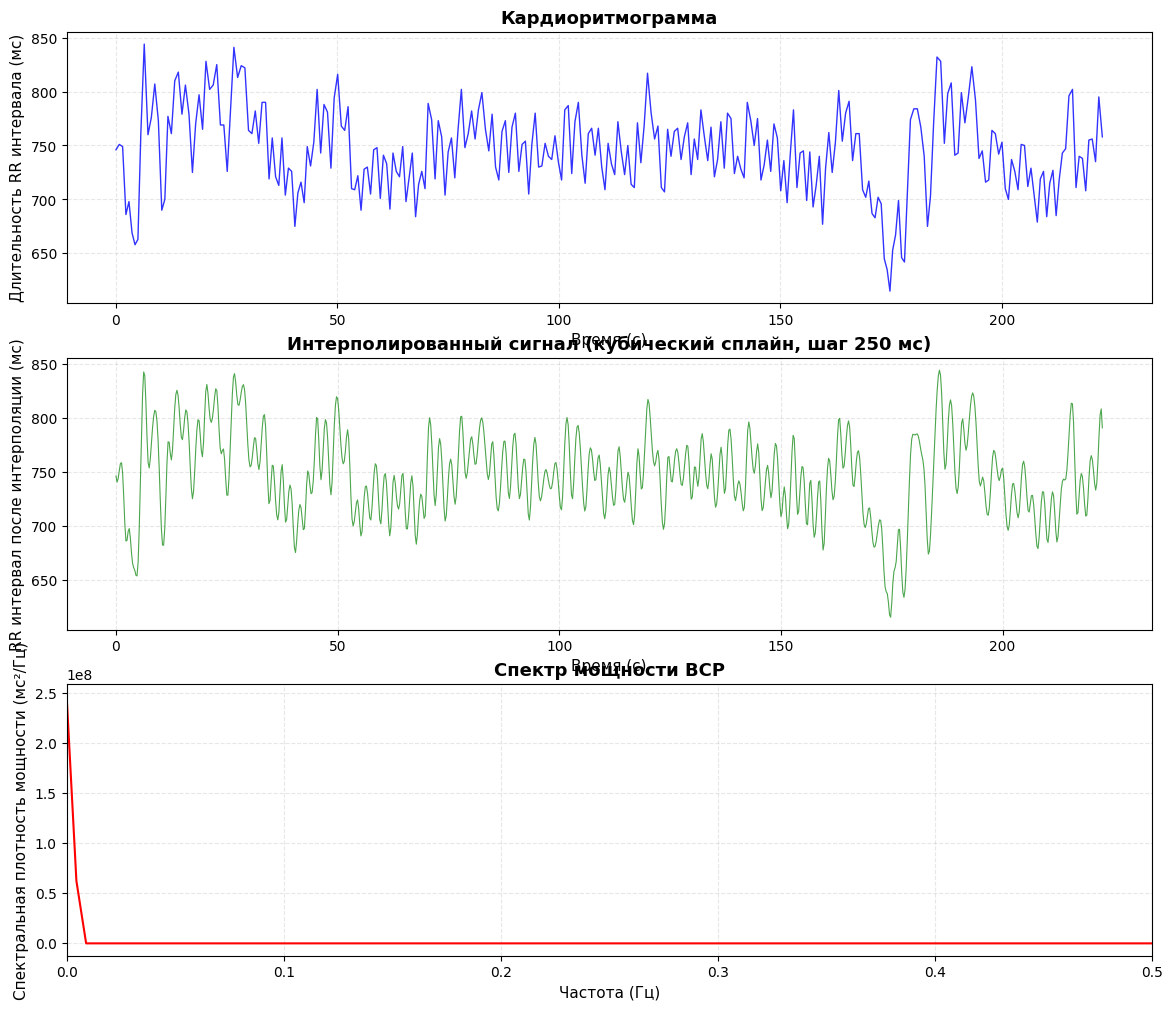

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# График 1: Кардиоритмограмма
axes[0].plot(time_points, rr_intervals, 'b-', linewidth=1, alpha=0.8)
axes[0].set_xlabel('Время (с)', fontsize=11)
axes[0].set_ylabel('Длительность RR интервала (мс)', fontsize=11)
axes[0].set_title('Кардиоритмограмма', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')

# График 2: Интерполированный сигнал
axes[1].plot(time_resampled, rr_resampled, 'g-', linewidth=0.8, alpha=0.7)
axes[1].set_xlabel('Время (с)', fontsize=11)
axes[1].set_ylabel('RR интервал после интерполяции (мс)', fontsize=11)
axes[1].set_title('Интерполированный сигнал (кубический сплайн, шаг 250 мс)',
                  fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')

# График 3: Спектральная плотность мощности
axes[2].plot(frequencies, psd_single, 'r-', linewidth=1.5)
axes[2].set_xlabel('Частота (Гц)', fontsize=11)
axes[2].set_ylabel('Спектральная плотность мощности (мс²/Гц)', fontsize=11)
axes[2].set_title('Спектр мощности ВСР', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].set_xlim(0, 0.5)


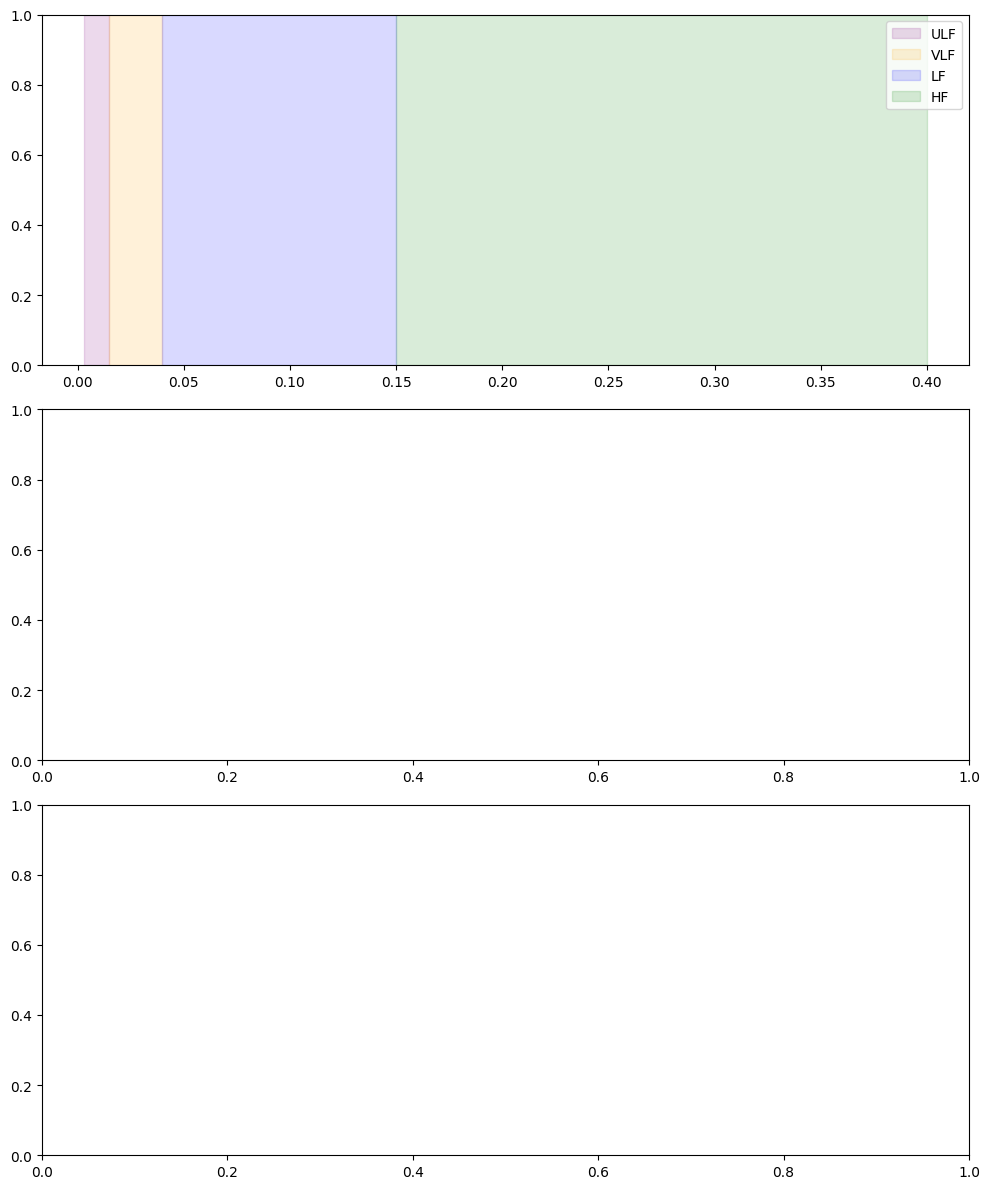

In [43]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Затем добавляете axvspan
axes[0].axvspan(ULF_range[0], ULF_range[1], alpha=0.15, color='purple', label='ULF')
axes[0].axvspan(VLF_range[0], VLF_range[1], alpha=0.15, color='orange', label='VLF')
axes[0].axvspan(LF_range[0], LF_range[1], alpha=0.15, color='blue', label='LF')
axes[0].axvspan(HF_range[0], HF_range[1], alpha=0.15, color='green', label='HF')
axes[0].legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()